# GNN Models — Training Diagnostics

Renders training curves and held-out-test diagnostics for every
`LineupGNN` variant. The base 2 × 2 grid (kind × mode) gets crossed with
two orthogonal axes: per-node feature blocks (label only / + xy /
+ stats) and graph architecture (template / dense). That gives 20
runs total.

| group | keys |
|---|---|
| template, label only      | `position_single`, `archetype_single`, `position_paired`, `archetype_paired` |
| template, + xy            | `*_single_coords`, `*_paired_coords` (×2 kinds) |
| template, + stats         | `*_single_stats`, `*_paired_stats` (×2 kinds) |
| dense, base               | `dense_position_single`, `dense_archetype_single`, `dense_position_paired`, `dense_archetype_paired` |
| dense, + stats            | `dense_*_single_stats`, `dense_*_paired_stats` (×2 kinds) |

The two architectures differ in three coupled choices:

| | template | dense |
|---|---|---|
| intra-team edges | formation template (4-3-3, 4-4-2, …) | fully connected |
| inter-team edges (paired only) | rule-based zone matchups | radial distance threshold (`--matchup-radius`, default 0.35) |
| pooling | `global_mean_pool` | `AttentionalAggregation` (shared gate) |
| xy coords | optional (`--use-coords`) | always on |

Each model is trained by `scripts/train_gnn.py` with the appropriate
flags (`--kind`, `--mode`, `--graph-arch {template,dense}`,
`--use-coords`, `--use-stats`). The shared match-blocked split is
`data/processed/{train,test}_snapshots.parquet` (from
`scripts/build_train_test_split.py`). Per-epoch metrics on the held-out
test parquet, the best-epoch test predictions, and a frozen
hyperparameter snapshot are written to
`artifacts/gnn_<kind>_<mode>[_coords|_stats]/` or
`artifacts/gnn_dense_<kind>_<mode>[_stats]/`. The internal `val_*`
naming in the log files is a Pytorch carryover — it refers to the test
set throughout.

This notebook stays thin — every plotting helper lives in
`models.training_plots` so the analysis can be reused outside Jupyter.


In [1]:
from __future__ import annotations
import sys
from pathlib import Path

HERE = Path.cwd()
ROOT = HERE
while ROOT != ROOT.parent and not (ROOT / 'configs' / 'config.yaml').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import pandas as pd

from models.training_plots import (
    MODEL_KEYS,
    PRETTY_LABEL,
    load_all_runs,
    plot_calibration,
    plot_loss_curves,
    plot_metric_overlays,
    plot_pred_vs_target_grid,
    plot_residual_hists,
    summary_table,
)

pd.set_option('display.width', 220)
ARTIFACTS = ROOT / 'artifacts'
print(f'reading runs from {ARTIFACTS}/')

reading runs from C:\Users\zcoch\dsc_148\DSC 148 Final Project\artifacts/


In [2]:
runs = load_all_runs(ARTIFACTS)
missing = [k for k in MODEL_KEYS if k not in runs]
print(f'loaded {len(runs)} run(s): {sorted(runs)}')
if missing:
    print(f'missing: {missing} — train with `python -m scripts.train_gnn --kind <k> --mode <m>`')

loaded 20 run(s): ['archetype_paired', 'archetype_paired_coords', 'archetype_paired_stats', 'archetype_single', 'archetype_single_coords', 'archetype_single_stats', 'dense_archetype_paired', 'dense_archetype_paired_stats', 'dense_archetype_single', 'dense_archetype_single_stats', 'dense_position_paired', 'dense_position_paired_stats', 'dense_position_single', 'dense_position_single_stats', 'position_paired', 'position_paired_coords', 'position_paired_stats', 'position_single', 'position_single_coords', 'position_single_stats']


## Summary table

Best-epoch metrics per model (lowest validation MSE).

In [3]:
summary_table(runs)

,best epoch,val MSE,val MAE,val R²,val Pearson r,val sign acc
model,,,,,,
"position, single",21,0.9665,0.5543,0.0052,0.0723,0.4390
"archetype, single",2,0.9416,0.5604,0.0309,0.1758,0.5840
"position, paired",13,0.9672,0.5534,0.0046,0.0701,0.4368
"archetype, paired",3,0.9425,0.5551,0.0299,0.1735,0.5798
"position, single + xy",8,0.9663,0.5552,0.0055,0.0744,0.4386
"archetype, single + xy",4,0.9421,0.5591,0.0304,0.1743,0.5804
"position, paired + xy",14,0.9680,0.5532,0.0037,0.0632,0.5288
"archetype, paired + xy",5,0.9422,0.5612,0.0302,0.1761,0.5761
"position, single + stats",21,0.9092,0.5571,0.0643,0.2535,0.6102


## Train vs validation MSE

One panel per model. Dashed line is validation; the highlighted dot marks the
best validation epoch (the checkpoint saved to disk).

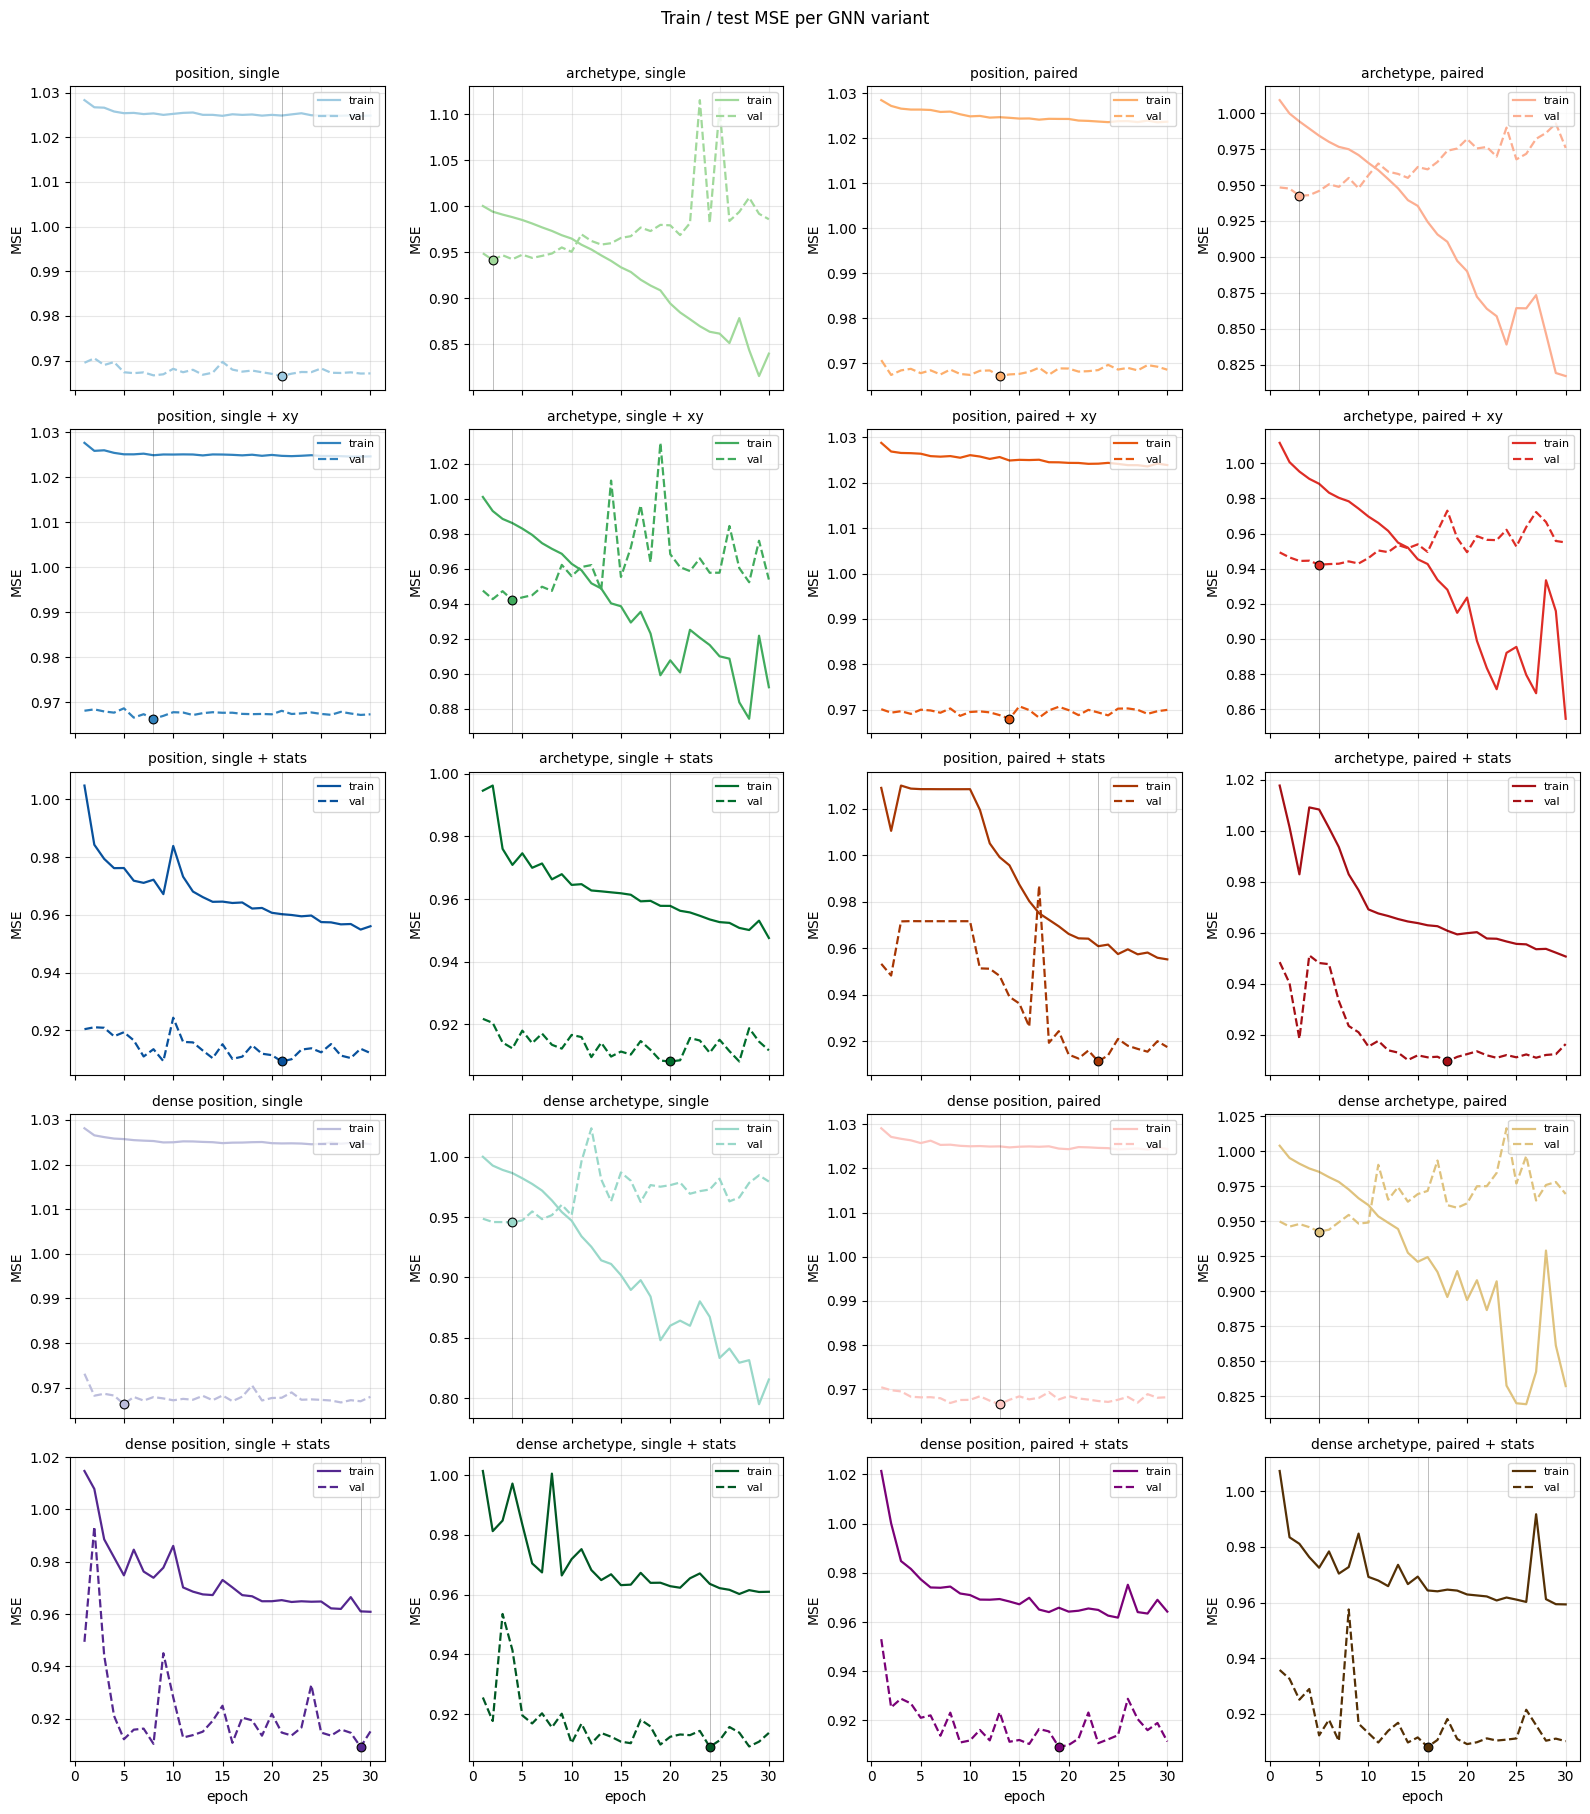

In [4]:
fig = plot_loss_curves(runs); plt.show()

## Validation metric overlays

All 4 models on one axis per metric so absolute differences (and how fast
they converge) are directly comparable.

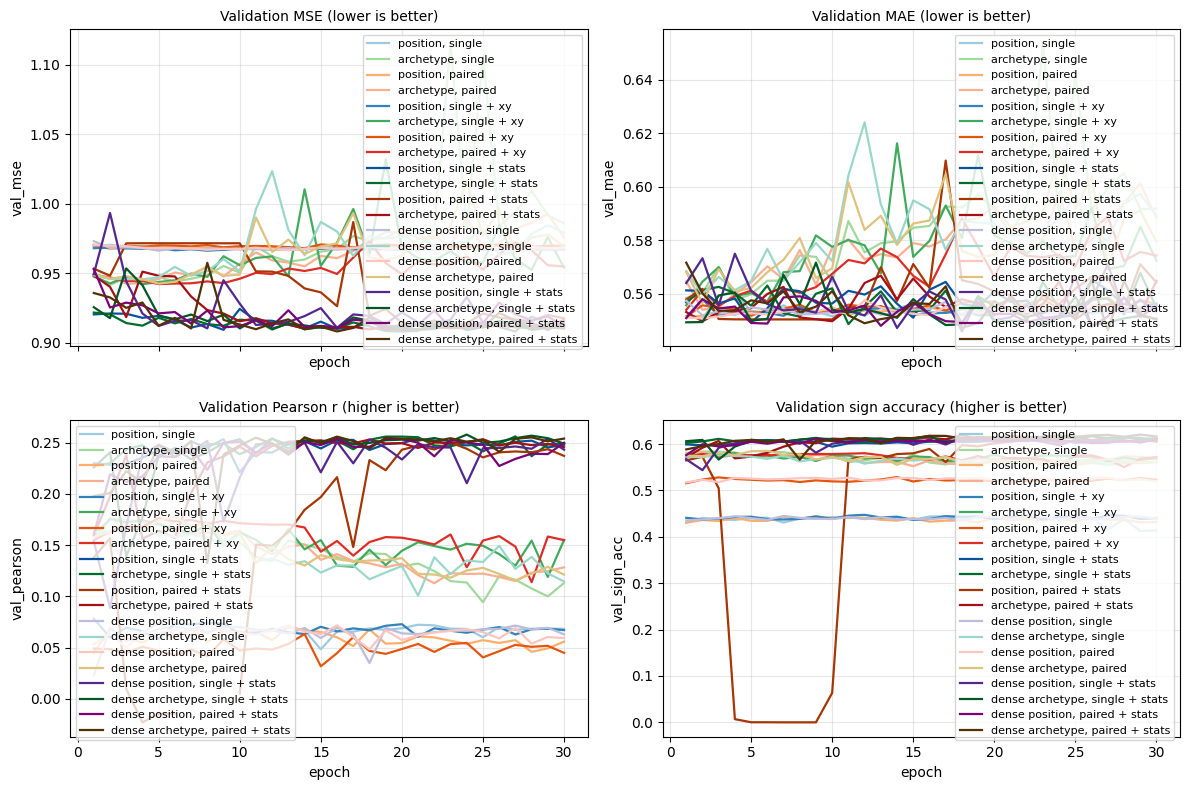

In [5]:
fig = plot_metric_overlays(
    runs,
    metrics=('val_mse', 'val_mae', 'val_pearson', 'val_sign_acc'),
)
plt.show()

## Optimization health

Gradient norm and learning rate per epoch. A grad norm that explodes or
collapses is the easiest signal that something is off with the optimizer.

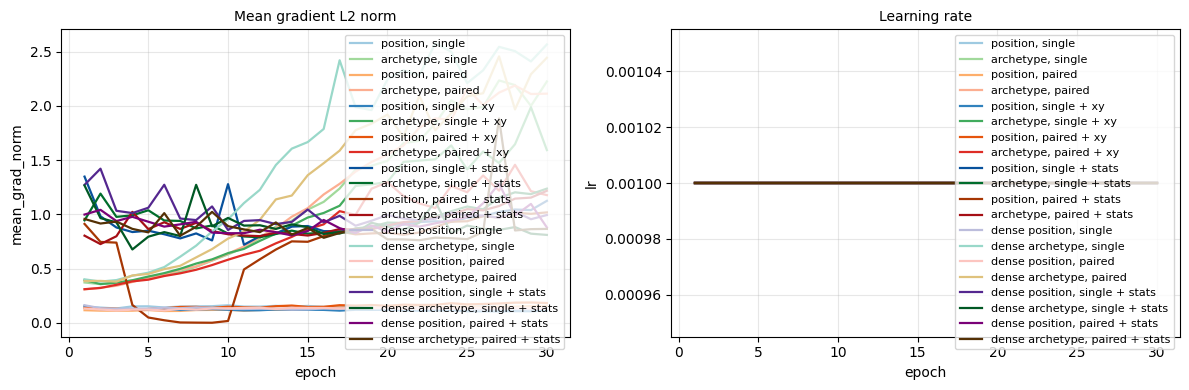

In [6]:
fig = plot_metric_overlays(
    runs,
    metrics=('mean_grad_norm', 'lr'),
    metric_titles={'lr': 'Learning rate'},
    figsize=(12, 4),
)
plt.show()

## Predictions vs targets (best epoch)

Dashed diagonal is the ideal calibration line. Pearson `r` in the title
summarises rank-consistency between predicted and observed differentials.

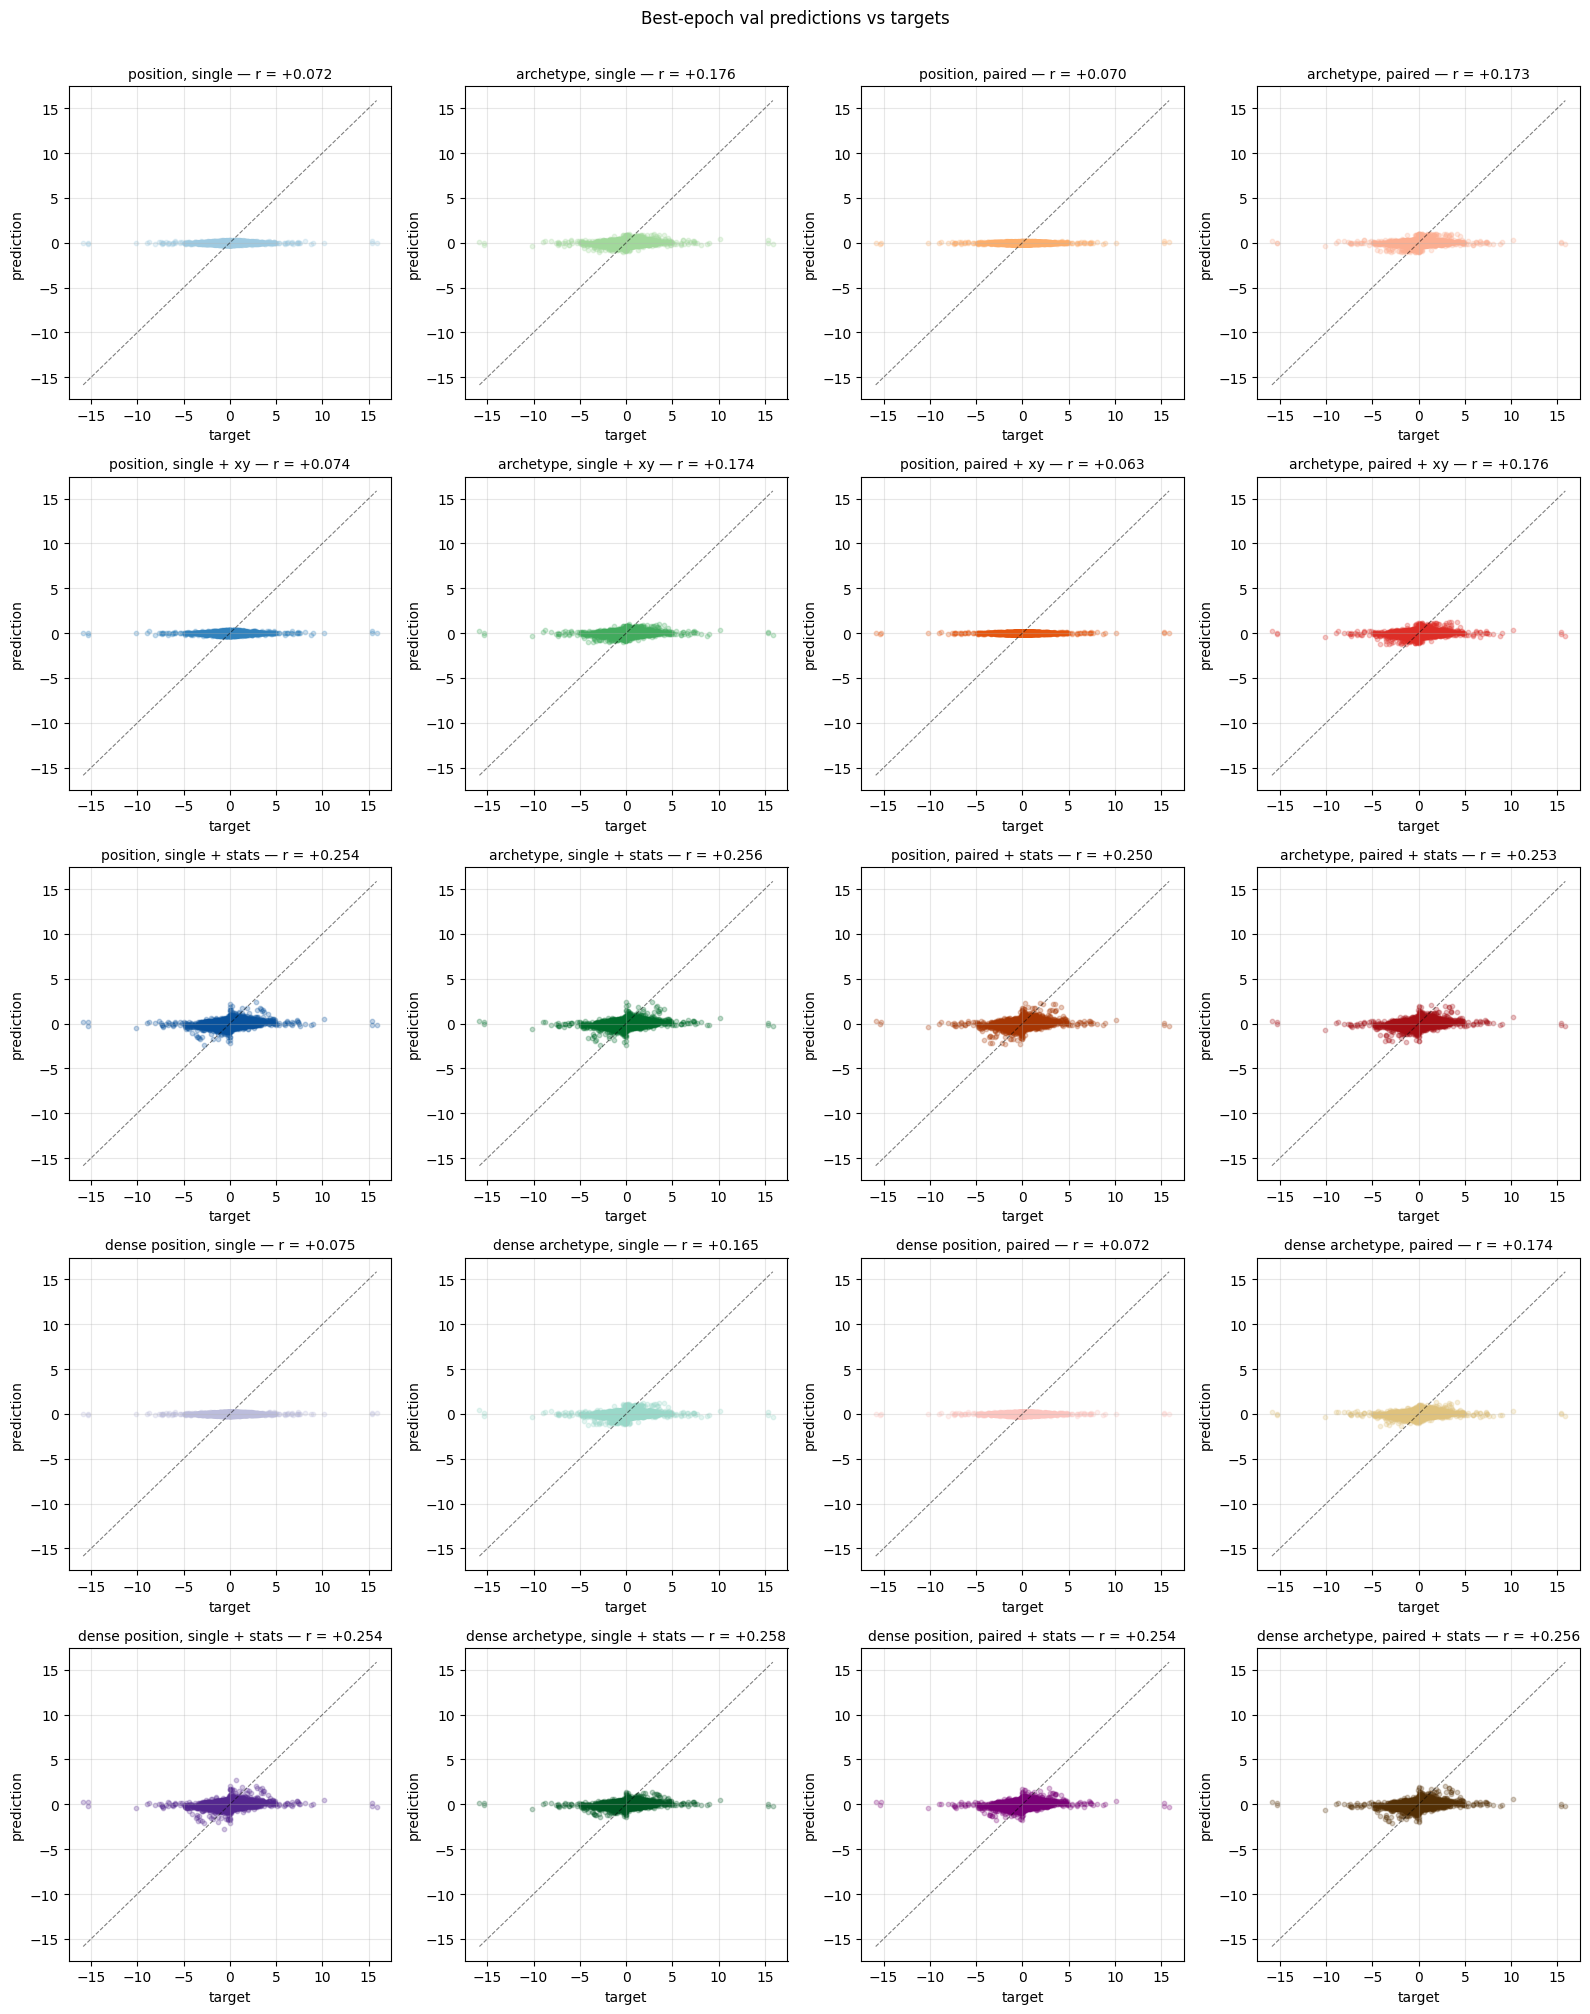

In [7]:
fig = plot_pred_vs_target_grid(runs); plt.show()

## Residual distributions (best epoch)

If a model's residual mean is meaningfully nonzero the head has a
systematic bias; the spread is an MSE-free view of how concentrated
the errors are.

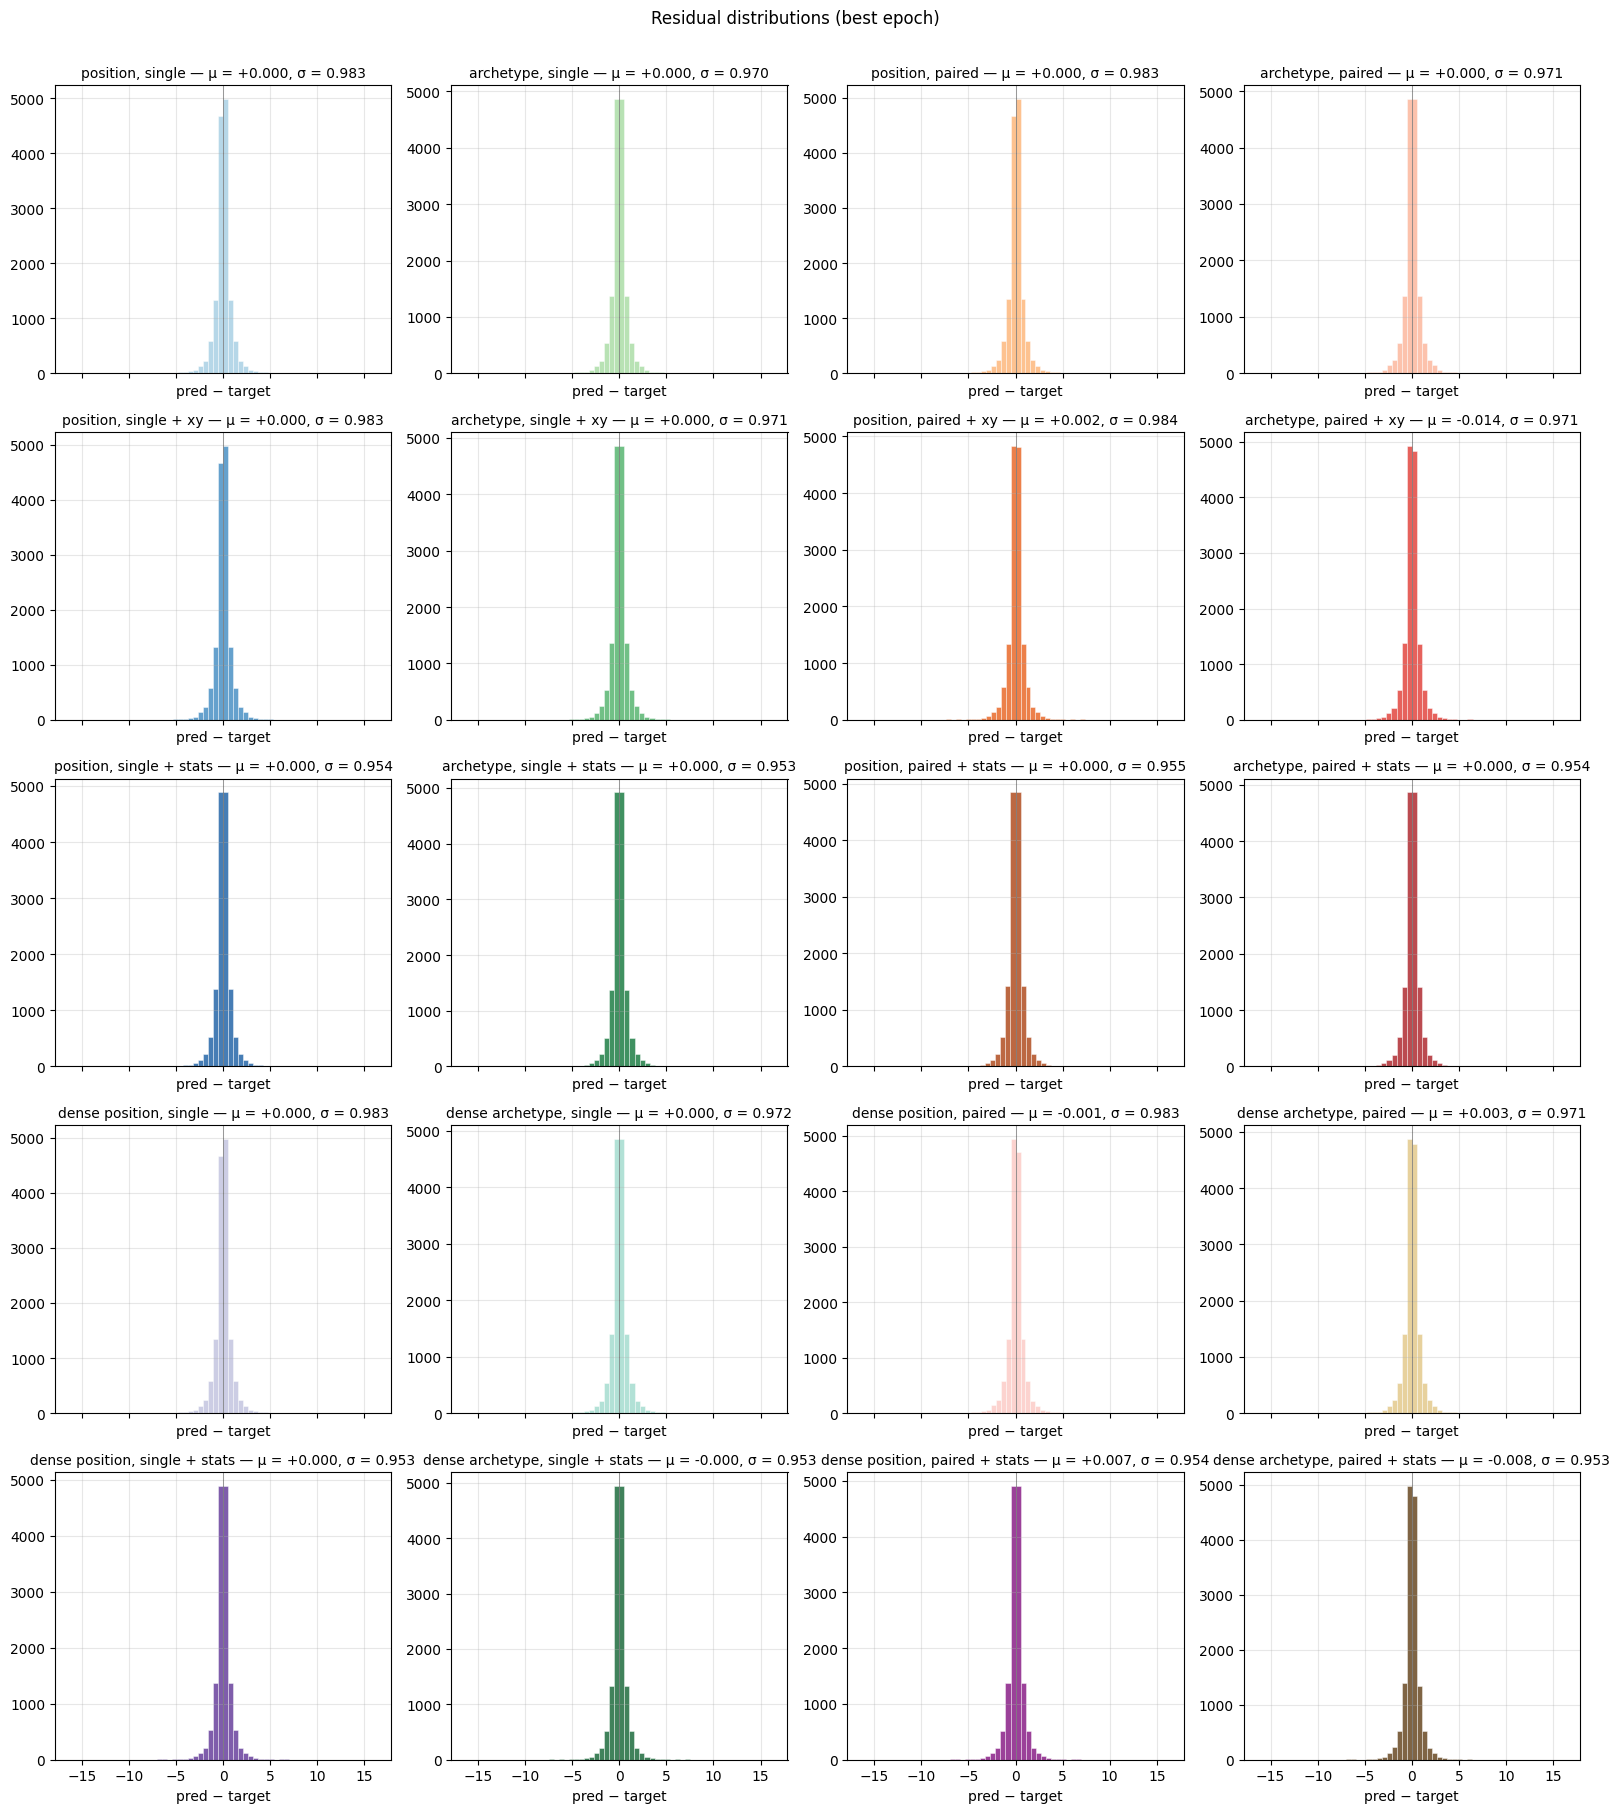

In [8]:
fig = plot_residual_hists(runs); plt.show()

## Reliability (mean target vs mean prediction by decile)

Sort predictions, bin into deciles, and plot (bin mean prediction, bin mean
target). A perfectly calibrated regressor sits on the diagonal.

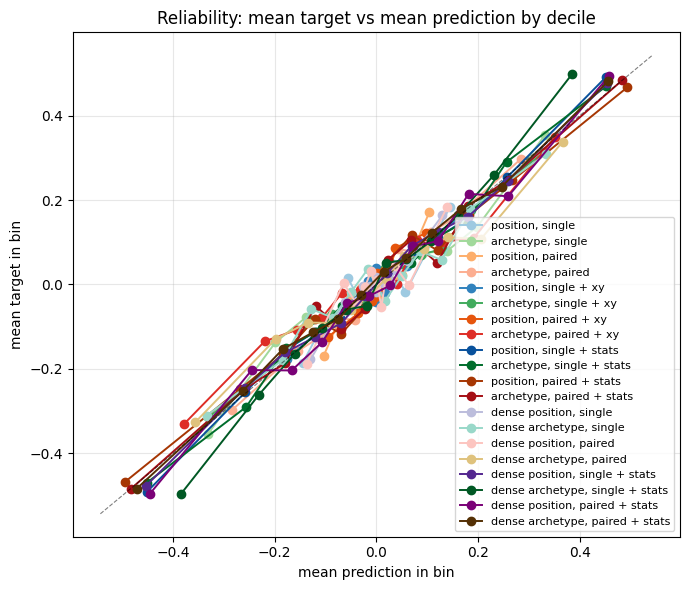

In [9]:
fig = plot_calibration(runs); plt.show()